In [7]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from pybaseball import batting_stats
import logging
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from arviz import hdi
from sklearn.metrics import root_mean_squared_error
import scipy.stats as stats
from scipy.special import logit

tf.get_logger().setLevel(logging.FATAL)  # suppress TF warnings

In [8]:
# --- Load data ---
raw_2018 = batting_stats(2018)
raw_2019 = batting_stats(2019)
raw_2021 = batting_stats(2021)
raw_2022 = batting_stats(2022)
raw_2023 = batting_stats(2023)
raw_2024 = batting_stats(2024)
raw_2025 = batting_stats(2025)

# --- Combine ---
raw_data = pd.concat([raw_2018, raw_2019, raw_2021, raw_2022, raw_2023, raw_2024, raw_2025])

# --- Select columns ---
#df = raw_data[["Season", "Name", "Team", "Pos", "Age", "PA", 
#               "AVG", "OBP", "SLG", "OPS", "xBA", "xwOBA", "K%", "Contact%", 
#               "EV", "Barrel%", "HardHit%"]]
df = raw_data[["Season", "Name", "Team", "Age", "PA", "AVG", "xBA"]]

# --- Filter for players with 500+ PA ---
df = df[df['PA'] >= 500].copy()

#save data
#raw_data.to_csv("C:/Users/Andrew/baseball/data/batting_stats_raw_2018_2025.csv", index=False)
#df.to_csv("C:/Users/Andrew/baseball/data/batting_stats_filtered_2018_2025.csv", index=False)

In [ ]:
# --- Sort by player and season ---
df = df.sort_values(['Name', 'Season']).reset_index(drop=True)

# --- Create next year AVG target ---
df['AVG_next'] = df.groupby('Name')['AVG'].shift(-1)

# --- Split into training and prediction sets ---
model_df = df[df['AVG_next'].notna()].copy()  # Training set - has AVG_next
model_df = model_df[model_df['Season'] != 2024].copy()  # #removing 2024 data - used to predict 2025 avg
df_2024 = df[df['Season'] == 2024].copy()     # Validation set - 2024 data & 2025 AVG's (AVG_next)

# --- Create new features ---
model_df['AVG_xBA'] = model_df['AVG'] * model_df['xBA'] # adding interaction term
df_2024['AVG_xBA'] = df_2024['AVG'] * df_2024['xBA'] # adding interaction term
model_df['Age2'] = model_df['Age'] **2 #add age^2
df_2024['Age2'] = df_2024['Age'] **2 #add age^2

# --- Set Features to Cross Validate ---
features = ["Age", "Age2", "AVG", "xBA", "AVG_xBA"] # batting average, expected batting average, and interaction
target = 'AVG_next'

# --- Standardize Features ---
scaler_X = StandardScaler()
X = scaler_X.fit_transform(model_df[features]) #standardize all features
X_2024 = scaler_X.transform(df_2024[features])  # use same scaler
y = model_df[target].values # not standardized but bounded inside [0,1] (on same scale)

In [10]:
print(pd.DataFrame(X, columns=features).corr())
#Going to use LOOCV to find best set of features

              Age      Age2       AVG       xBA   AVG_xBA
Age      1.000000  0.996538 -0.022894 -0.001650 -0.014144
Age2     0.996538  1.000000 -0.019415  0.003970 -0.009590
AVG     -0.022894 -0.019415  1.000000  0.797608  0.954499
xBA     -0.001650  0.003970  0.797608  1.000000  0.937187
AVG_xBA -0.014144 -0.009590  0.954499  0.937187  1.000000


In [ ]:
logit_mean = -1.429
traces = {}

model_specs = {
    #Excluding Age
    "AVG":                  ["AVG"],
    "xBA":                  ["xBA"],
    "AVG+xBA":              ["AVG", "xBA"],
    "AVG+xBA+interact":     ["AVG", "xBA", "AVG_xBA"],
    #Including both Age and Age2
    "Age+AVG":              ["Age", "Age2", "AVG"],
    "Age+xBA":              ["Age", "Age2", "xBA"],
    "Age+AVG+xBA":          ["Age", "Age2", "AVG", "xBA"],
    "Age+AVG+xBA+interact": ["Age", "Age2", "AVG", "xBA", "AVG_xBA"],
    #Only Age2
    "Age2+AVG":              ["Age2", "AVG"],
    "Age2+xBA":              ["Age2", "xBA"],
    "Age2+AVG+xBA":          ["Age2", "AVG", "xBA"],
    "Age2+AVG+xBA+interact": ["Age2", "AVG", "xBA", "AVG_xBA"]
}

for model_name, feature_list in model_specs.items():
    print(f"\nFitting: {model_name}")
    
    X_sub = X[:, [features.index(f) for f in feature_list]]
    
    with pm.Model(coords={"features": feature_list}) as m:
        X_data = pm.Data('X_data', X_sub)
        y_data = pm.Data('y_data', y)

        alpha = pm.Normal('alpha', mu=logit_mean, sigma=0.33)
        betas = pm.Normal('betas', mu=0, sigma=1.0, dims="features")

        mu = pm.Deterministic('mu', pm.math.sigmoid(alpha + (X_data * betas).sum(axis=1)))
        kappa = pm.HalfNormal('kappa', sigma=20)

        y_obs = pm.Beta('y_obs', mu=mu, nu=kappa, observed=y_data)  

        trace = pm.sample(1000, tune=1000, chains=4, target_accept=0.85, cores=8, progressbar=True)
        pm.compute_log_likelihood(trace)
        
    traces[model_name] = trace  # outside with block


# 12m 24.9s with 1000 samples, 1000 tune, 4 chains, 4 cores 
# 14m 34.3s with 1000 samples, 1000 tune, 4 chains, 8 cores 


Fitting: AVG


c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, kappa]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 49 seconds.


Output()

...


Fitting: Age2+AVG+xBA+interact


c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, kappa]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 90 seconds.


Output()

                       rank     elpd_loo     p_loo  elpd_diff        weight  \
Age2+AVG+xBA              0  1066.699744  3.074749   0.000000  6.749825e-01   
AVG+xBA                   1  1066.552406  2.409843   0.147338  3.250175e-01   
AVG+xBA+interact          2  1065.665555  3.185739   1.034189  0.000000e+00   
Age2+AVG+xBA+interact     3  1065.662540  3.759855   1.037204  0.000000e+00   
Age+AVG+xBA               4  1065.376480  3.802296   1.323264  0.000000e+00   
Age+AVG+xBA+interact      5  1064.527837  4.450523   2.171907  0.000000e+00   
AVG                       6  1063.915682  1.630575   2.784062  3.018332e-15   
Age2+AVG                  7  1063.777602  2.294280   2.922142  3.604771e-15   
Age+AVG                   8  1062.866999  2.999528   3.832745  0.000000e+00   
xBA                       9  1062.252311  1.872916   4.447433  0.000000e+00   
Age2+xBA                 10  1062.247691  2.557140   4.452053  0.000000e+00   
Age+xBA                  11  1061.349012  3.151658  

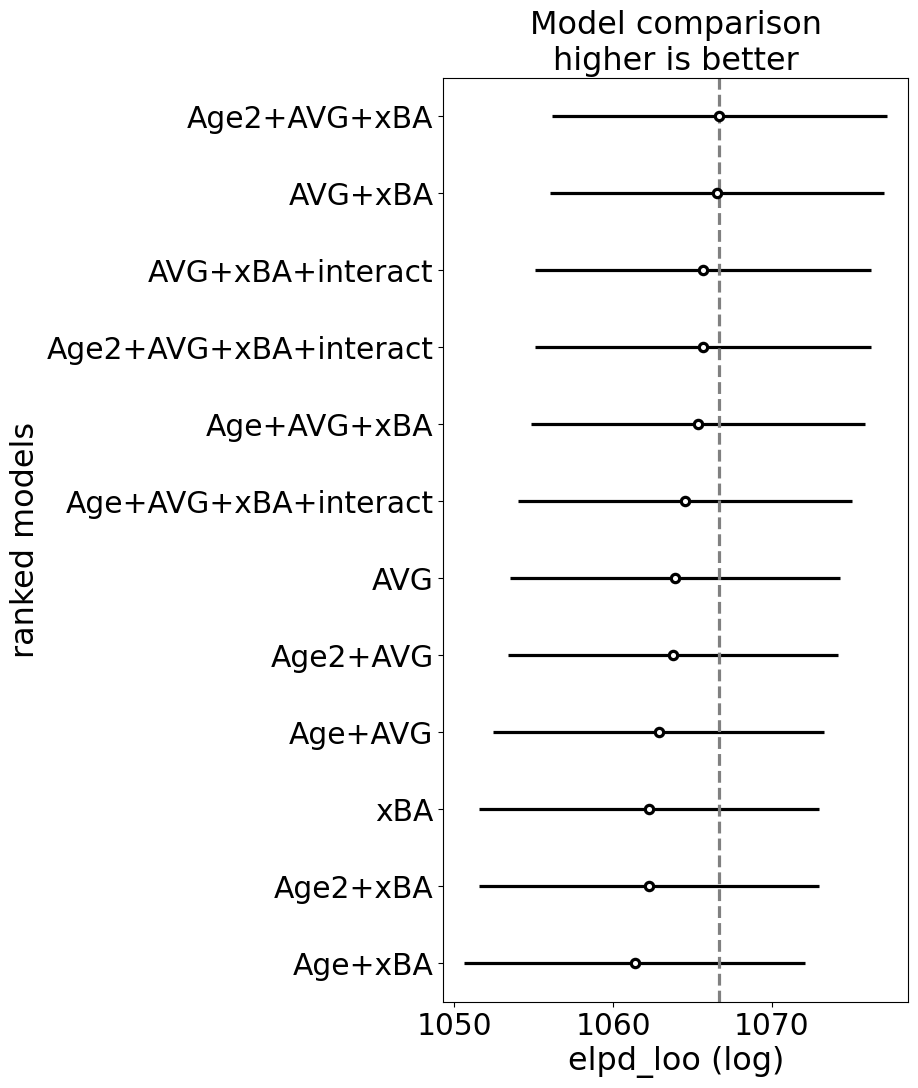

In [13]:
comparison = az.compare(traces, ic="loo", scale="log")
print(comparison)
az.plot_compare(comparison)
plt.show()